- Topic: **Fraction of symptomatics** scheme
- Creation date: 07/2025
- Author: Miguel Garrido Zornoza (mgarrizoraca@gmail.com)

In [1]:
from datetime import datetime
from IPython.display import display, Markdown

todays_date = str(datetime.now().date())

display(Markdown(f'#### Last update: {todays_date}'))

#### Last update: 2025-07-17

In [310]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.colors as colors

Linear scheme for symptomatic fraction

$$ \alpha(e_l) = -(\alpha_{max} - \alpha_{min}) \cdot e_l + \alpha_{max}$$

parameters: 
- $\alpha_{max} = 1$
- $\alpha_{min} \sim 0.25$

Sigmoidal scheme for symptomatic fraction

$$ \alpha(e_l) = \alpha_{max}\cdot \left(1 - \frac{1}{\alpha_{max}/(\alpha_{max}-\alpha_{min}) + e^{-m(e_l-e_m)}} \right)$$

parameters: 
- $\alpha_{max} = 1$
- $\alpha_{min} \sim 0.28$
- $m = \text{free}$
- $b = \alpha_{max}/(\alpha_{max}-\alpha_{min})$
- $e_m = \text{free} \in [0,1]$ 

In [311]:
def sig(e,e_m,a,b,m):
    return a*(1 - 1/(b+np.exp(-m*(e-e_m))))

def lin(x,α_min):
    return -(1-α_min)*x + 1

def inflection(e_m,α_max,α_min,m):
    return e_m - 1/m*np.log(2-α_max/(α_max-α_min))

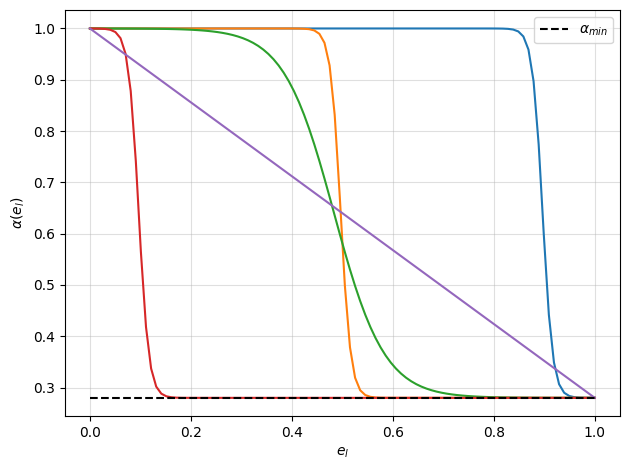

In [312]:
x = np.linspace(0,1,100)

α_max = 1
α_min = 0.28
#plt.plot(x,sig(x,0,1,1/(1-α_min),0.05), label ="b")


plt.plot(x,sig(x,0.9,α_max,α_max/(α_max-α_min),100))
plt.plot(x,sig(x,0.5,α_max,α_max/(α_max-α_min),100))
plt.plot(x,sig(x,0.5,α_max,α_max/(α_max-α_min),20))
plt.plot(x,sig(x,0.1,α_max,α_max/(α_max-α_min),100))

plt.plot(x,lin(x,α_min))

plt.hlines(α_min,0,1, ls = "dashed", color = "k", label = r"$\alpha_{min}$")

plt.ylabel(r"$\alpha(e_l)$")
plt.xlabel(r"$e_l$")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()

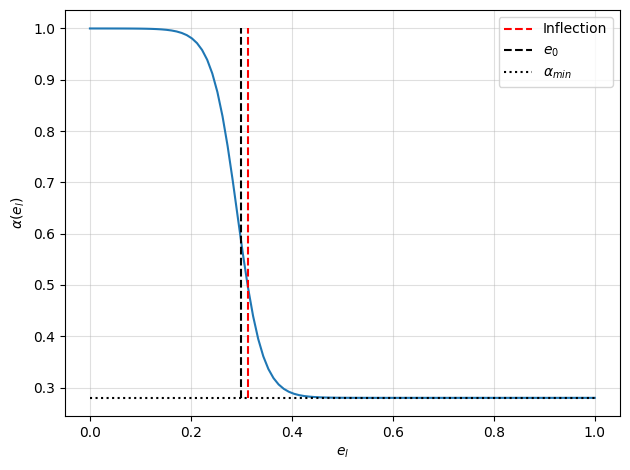

In [337]:
x = np.linspace(0,1,100)

α_max = 1
α_min = 0.28
e_m = 0.3
m = 40

plt.plot(x,sig(x,e_m,α_max,α_max/(α_max-α_min),m))

plt.vlines(inflection(e_m,α_max,α_min,m),α_min,1, ls = "dashed", label = "Inflection", color = "red")
plt.vlines(e_m,α_min,1, ls = "dashed", label = r"$e_0$", color = "k")


plt.hlines(α_min,0,1, ls = "dotted", color = "k", label = r"$\alpha_{min}$")

plt.ylabel(r"$\alpha(e_l)$")
plt.xlabel(r"$e_l$")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()

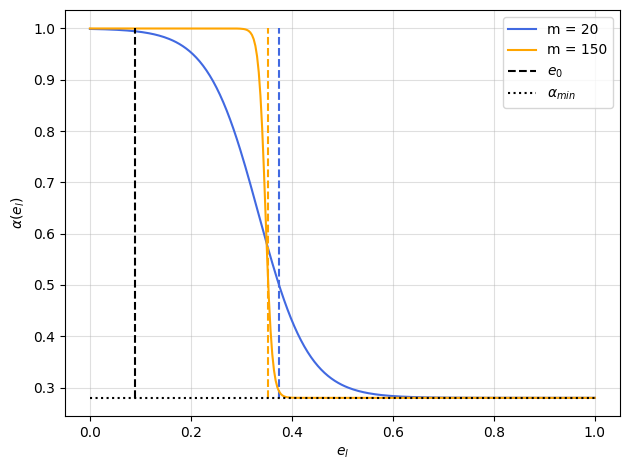

In [338]:
x = np.linspace(0,1,300)

α_max = 1
α_min = 0.28
e_m = 0.35

color_list = ["royalblue","orange","red"]
counter = 0

for m in [20, 150]:
    plt.plot(x,sig(x,e_m,α_max,α_max/(α_max-α_min),m), color = color_list[counter], label = f"m = {m}")
    plt.vlines(inflection(e_m,α_max,α_min,m),α_min,1, ls = "dashed", color = color_list[counter])
    csum = np.cumsum(1-sig(x,e_m,α_max,α_max/(α_max-α_min),m))
    #plt.plot(x,csum/csum[-1], color = color_list[counter], ls = "dotted")
    counter += 1

plt.vlines(0.09,α_min,1, ls = "dashed", label = r"$e_0$", color = "k")
plt.hlines(α_min,0,1, ls = "dotted", color = "k", label = r"$\alpha_{min}$")

plt.ylabel(r"$\alpha(e_l)$")
plt.xlabel(r"$e_l$")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()

$$ \mu_{i} = r_i \cdot \left( \frac{1-p}{p} + IPP \right)$$

$$ \sum_{i = 0}^{r_i} e_l^{+}(e_l) \sim e_{l_i}$$ 

We now build the $\mu_i(e_l,EIR)$ heat map

In [339]:
def delta(x,e1,e2,e0,A1):
    return A1*e0*np.exp(-x/e1) + (1-A1)*e0*np.exp(-x/e2)

def sum_to_level(l,e0,e1,e2,A1):
    summ = 0.
    counter = 0
    cycle = True
    while cycle:
        summ += delta(summ,e1,e2,e0,A1)
        counter += 1

        if (summ >= l):
            cycle = False
    return counter

In [340]:
A1 = 0.9
e0 = 0.09
e1 = 0.5*e0
e2 = 10*e0
IPP = 10
P_v0 = 0.3

In [341]:
EIR = np.linspace(1,150,int(5e2))
imm = np.linspace(0,1,int(5e2))

μ = np.zeros((len(imm),len(EIR)))

for j,EIR_a in tqdm(enumerate(EIR)):
    p = 1-np.exp(-EIR_a*P_v0/365)
    
    for i,e in enumerate(imm):
        μ[i][j] = sum_to_level(e,e0,e1,e2,A1)*((1-p)/p + IPP)
      #  print(e,sum_to_level(e,e0,e1,e2,A1)*((1-p)/p + IPP),EIR_a)

500it [00:18, 26.55it/s]


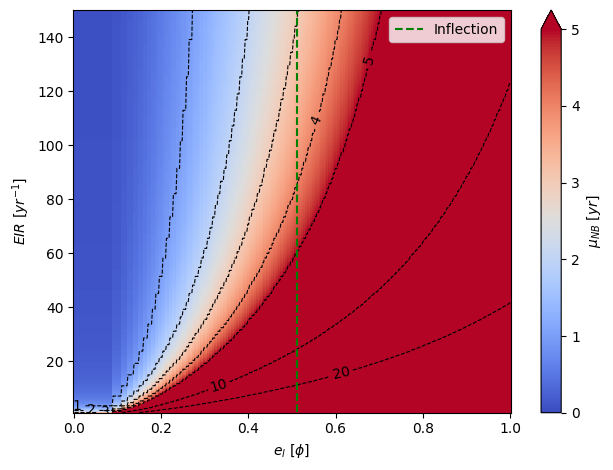

In [345]:
Y, X = np.meshgrid(EIR,imm)

fig, ax = plt.subplots()
CM = plt.contour(X, Y, μ/365, levels=[1,2,3,4,5,10,20], colors='k', linestyles = "dashed", linewidths=0.8) # 10 levels, white lines
ax.clabel(CM, CM.levels)

cb = plt.pcolor(X, Y, μ/365, cmap = "coolwarm", vmin = 0, vmax = 5)
#cb = plt.pcolor(X, Y, μ, norm = colors.LogNorm(vmin=10**0,vmax=10**3), cmap = "coolwarm")
plt.colorbar(cb, location='right', anchor=(0.05, 0.1), shrink=1., extend = "max", label = r"$\mu_{NB} \ [yr]$")
plt.clim(0,5)

α_max = 1
α_min = 0.28
e_m = 0.5
m = 40

plt.vlines(inflection(e_m,α_max,α_min,m),EIR[0],EIR[-1], ls = "dashed", label = "Inflection", color = "green")

plt.ylabel(r"$EIR \ [yr^{-1}]$")
plt.xlabel(r"$e_l \ [\phi]$")

plt.legend()
plt.tight_layout()

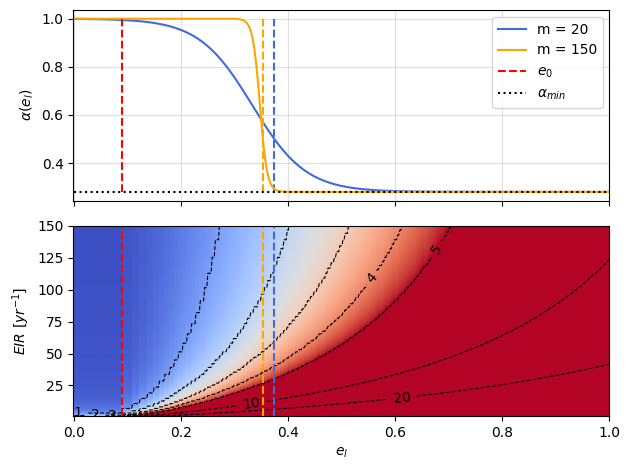

In [360]:
plt.subplots(2,1, sharex = True)

plt.subplot(2,1,1)
x = np.linspace(0,1,300)

α_max = 1
α_min = 0.28
e_m = 0.35

color_list = ["royalblue","orange","red"]
counter = 0

for m in [20, 150]:
    plt.plot(x,sig(x,e_m,α_max,α_max/(α_max-α_min),m), color = color_list[counter], label = f"m = {m}")
    plt.vlines(inflection(e_m,α_max,α_min,m),α_min,1, ls = "dashed", color = color_list[counter])
    csum = np.cumsum(1-sig(x,e_m,α_max,α_max/(α_max-α_min),m))
    #plt.plot(x,csum/csum[-1], color = color_list[counter], ls = "dotted")
    counter += 1

plt.vlines(0.09,α_min,1, ls = "dashed", label = r"$e_0$", color = "red")
plt.hlines(α_min,0,1, ls = "dotted", color = "k", label = r"$\alpha_{min}$")

plt.ylabel(r"$\alpha(e_l)$")
plt.legend()
plt.grid(alpha=0.4)

plt.subplot(2,1,2)

CM = plt.contour(X, Y, μ/365, levels=[1,2,3,4,5,10,20], colors='k', linestyles = "dashed", linewidths=0.8) # 10 levels, white lines
ax.clabel(CM, CM.levels)

cb = plt.pcolor(X, Y, μ/365, cmap = "coolwarm", vmin = 0, vmax = 5)
#plt.colorbar(cb, location='right', anchor=(0.05, 0.1), shrink=1., extend = "max", label = r"$\mu_{NB} \ [yr]$")
#plt.clim(0,5)
plt.xlabel(r"$e_l$")
plt.ylabel(r"$EIR \ [yr^{-1}]$")

plt.vlines(inflection(0.35,α_max,α_min,150),EIR[0],EIR[-1], ls = "dashed", label = "Inflection", color = "orange")
plt.vlines(inflection(0.35,α_max,α_min,20),EIR[0],EIR[-1], ls = "dashed", label = "Inflection", color = "royalblue")
plt.vlines(0.09,EIR[0],EIR[-1], ls = "dashed", label = r"$e_0$", color = "red")


plt.tight_layout()

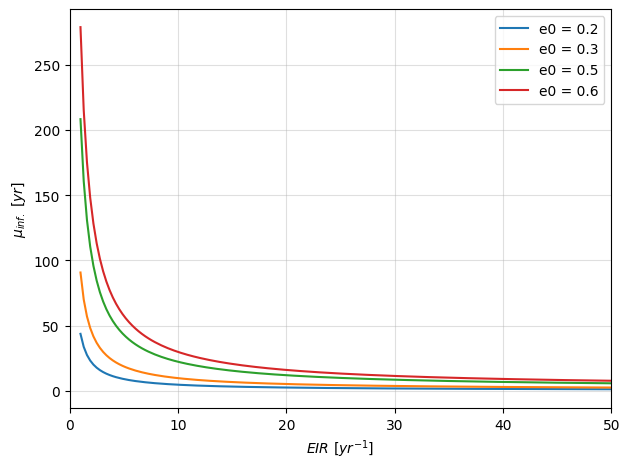

In [346]:
plt.subplots(dpi=100)

for e0 in [0.2,0.3,0.5,0.6]:
    indx = np.abs(imm-inflection(e0,α_max,α_min,m)).argmin()
    plt.plot(EIR, μ[indx]/365, label = f"e0 = {e0:.1f}")

plt.xlabel(r"$EIR \ [yr^{-1}]$")
plt.ylabel(r"$\mu_{inf.} \ [yr]$")

plt.legend()
plt.xlim(0,50)
plt.grid(alpha=0.4)
plt.tight_layout()

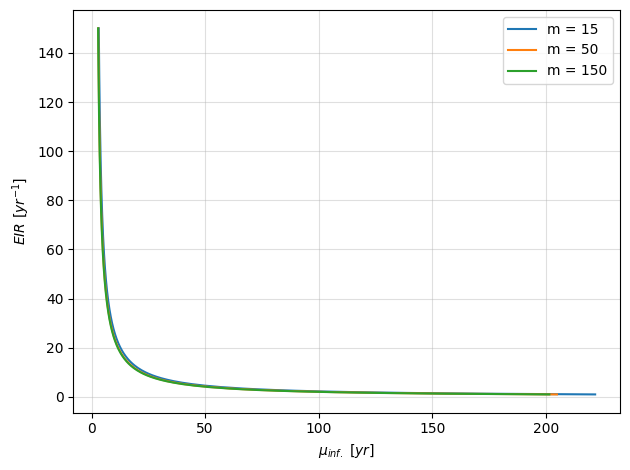

In [347]:
plt.subplots(dpi=100)

e0 = 0.5
for m in [15, 50, 150]:
    indx = np.abs(imm-inflection(e0,α_max,α_min,m)).argmin()
    plt.plot(μ[indx]/365,EIR, label = f"m = {m:.0f}")

plt.ylabel(r"$EIR \ [yr^{-1}]$")
plt.xlabel(r"$\mu_{inf.} \ [yr]$")

plt.legend()
#plt.xlim(0,20)
plt.grid(alpha=0.4)
plt.tight_layout()